In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [7]:
train_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/digit-recognizer/test.csv")

In [8]:
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
train_df.shape

(42000, 785)

In [10]:
test_df.shape

(28000, 784)

In [11]:
x = train_df.drop('label', axis = 1)
y = train_df['label']

In [14]:
image = x.iloc[0].values

In [15]:
image = image.reshape(28,28)

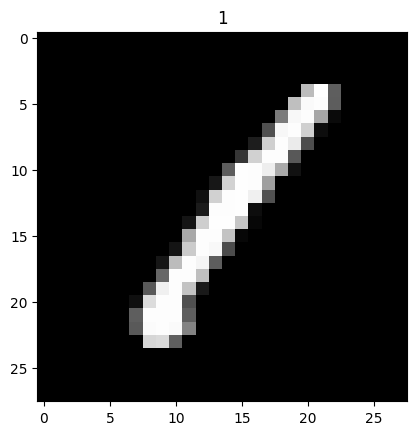

In [16]:
plt.imshow(image, cmap = 'gray')
plt.title(y.iloc[0])
plt.show()

In [18]:
x = x / 255.0

test_df = test_df / 255.0

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [20]:
x_train.shape

(33600, 784)

In [21]:
x_val.shape

(8400, 784)

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-06-04 05:53:46.787566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780552427.095879      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780552427.172217      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780552427.898368      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780552427.898409      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780552427.898413      58 computation_placer.cc:177] computation placer alr

In [23]:
model = Sequential([
    Dense(128, activation = 'relu', input_shape=(784,)),
    Dense(64, activation = 'relu'),
    Dense(10, activation = 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-04 05:55:45.524337: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [24]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [25]:
history = model.fit(
    x_train, y_train, validation_data = (x_val, y_val), epochs = 10
)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9142 - loss: 0.2989 - val_accuracy: 0.9488 - val_loss: 0.1696
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9627 - loss: 0.1246 - val_accuracy: 0.9548 - val_loss: 0.1484
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9735 - loss: 0.0849 - val_accuracy: 0.9667 - val_loss: 0.1123
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9807 - loss: 0.0622 - val_accuracy: 0.9682 - val_loss: 0.1103
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9841 - loss: 0.0484 - val_accuracy: 0.9676 - val_loss: 0.1131
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9880 - loss: 0.0364 - val_accuracy: 0.9708 - val_loss: 0.1086
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9906 - loss: 0.0294 - val_accuracy: 0.9619 - val_loss: 0.1432
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9917 - loss: 0.0252 - 

In [26]:
model.evaluate(x_val, y_val)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9717 - loss: 0.1192


[0.11921960860490799, 0.971666693687439]

In [28]:
predictions = model.predict(test_df)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [29]:
predictions = np.argmax(predictions, axis = 1)

In [30]:
predictions

array([2, 0, 9, ..., 3, 9, 2], shape=(28000,))

In [32]:
submission = pd.DataFrame({
    'ImageId': range(1, len(predictions)+1),
    'Label': predictions
})

In [34]:
submission.to_csv('submission_1.csv',index = False)